In [1]:
# ── Imports ──
# Jose Ramirez V1 — logistic regression HR model
# Key differences from Julio V2:
#   - pitcher_r dropped: Ramirez is a switch hitter, handedness matchup is neutralized by design
#   - Progressive Field park_factor_hr = 63 — one of the most suppressive parks in MLB
#     is_home expected to be strongly negative, opposite of a neutral park player
#   - k_per_9 retained: Ramirez adjusts approach based on pitcher profile like Julio
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Jose Ramirez player_id = 608070, team_id = 114 (Cleveland Guardians)
PLAYER_ID = 608070

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 114
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (645, 12)
         date  hr  tb   era
0  2022-04-07   0   2  4.20
1  2022-04-09   0   1  4.20
2  2022-04-10   1   7  4.20
3  2022-04-11   0   1  4.20
4  2022-04-12   1   8  0.00
5  2022-04-13   1   7  4.20
6  2022-04-15   0   2  1.80
7  2022-04-16   0   2  4.91
8  2022-04-17   0   1  4.15
9  2022-04-20   1   4  5.40


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Julio: 17.4% for comparison)")


HR distribution:
hr
0    533
1    102
2      8
3      2
Name: count, dtype: int64

Games with 0 HR:  0.826
Games with 1+ HR: 0.174 (17.4% of games)
Games with 2+ HR: 0.016

Break-even American odds: -21

(Witt: 16.0%, Julio: 17.4% for comparison)


In [4]:
# ── Pull Statcast data via pybaseball ──
# Jose Ramirez player_id = 608070
# Ramirez has Statcast data going back to 2015 — starting 2022 for consistency
# with other players and to avoid pre-Statcast era noise
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=608070)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (11843, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))


Game-level Statcast: (644, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-04     0.000000      0.000000
1  2022-04-05     0.000000      0.000000
2  2022-04-07     0.000000      0.000000
3  2022-04-09     0.000000      0.142857
4  2022-04-10     0.285714      0.000000
5  2022-04-11     0.000000      0.000000
6  2022-04-12     0.066667      0.200000
7  2022-04-13     0.250000      0.000000
8  2022-04-15     0.333333      0.666667
9  2022-04-16     0.000000      0.000000


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))


     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-04             NaN              NaN
1   2022-04-05             NaN              NaN
2   2022-04-07             NaN              NaN
3   2022-04-09             NaN              NaN
4   2022-04-10             NaN              NaN
5   2022-04-11             NaN              NaN
6   2022-04-12             NaN              NaN
7   2022-04-13        0.050340         0.048980
8   2022-04-15        0.075298         0.042857
9   2022-04-16        0.103968         0.112169
10  2022-04-17        0.093571         0.100952
11  2022-04-20        0.096429         0.114502
12  2022-04-21        0.094803         0.111371
13  2022-04-22        0.087511         0.102804
14  2022-04-23        0.081260         0.095460
15  2022-04-24        0.075842         0.100208
16  2022-04-25        0.075842         0.100208
17  2022-04-26        0.075842         0.100208
18  2022-04-27        0.075842         0.111319
19  2022-04-28        0.081903         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())


After merge: (645, 17)
avg_exit_velo_15    21
barrel_rate_15      21
hr_zone_rate_15     21
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home'] = (df['home_away'] == 'home').astype(int)

# pitcher_r intentionally omitted — Ramirez is a switch hitter
# He bats left vs RHP, right vs LHP, neutralizing the platoon split
# pitcher handedness carries no meaningful signal for him

# Progressive Field park_factor_hr = 63 — strongly suppressive
# is_home expected to show a clear negative coefficient
# road games in hitter parks (Coors 126, Citizens Bank 117) are the opportunity

df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (624, 18)


In [9]:
# ── Define features and binary target ──
# Ramirez V1 — 8 features
# pitcher_r dropped vs Julio V2 (switch hitter — handedness neutralized)
# k_per_9 retained — Ramirez adjusts approach to pitcher profile like Julio,
#   high K/9 pitchers may suppress his HR rate
FEATURES = [
    # Contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    # Pitcher
    'era',
    'k_per_9',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Julio: 0.174 for comparison)")


Features: 8
Dataset: (624, 8)
HR rate: 0.173 (108 HR games out of 624)

(Witt: 0.160, Julio: 0.174 for comparison)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)


In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")


Baseline accuracy (always predict no HR): 0.827
Break-even odds for HR prop: -21


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))


Best C:        0.01
Best CV AUC:   0.488

 param_C  mean_test_score  std_test_score
   0.001           0.4877          0.0735
   0.010           0.4882          0.0715
   0.050           0.4836          0.0623
   0.100           0.4814          0.0552
   0.250           0.4762          0.0469
   0.500           0.4736          0.0382
   1.000           0.4735          0.0358
   2.000           0.4735          0.0351
   5.000           0.4731          0.0340
  10.000           0.4734          0.0335


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nRamirez V1 CV AUC: {cv_auc.mean():.3f}")
print(f"Julio V2 CV AUC:   0.566")
print(f"Witt V10 CV AUC:   0.567")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.422), np.float64(0.623), np.float64(0.436), np.float64(0.486), np.float64(0.474)]
CV ACC per fold:  [np.float64(0.885), np.float64(0.856), np.float64(0.75), np.float64(0.837), np.float64(0.808)]

AUC mean +/- std: 0.488 +/- 0.071
ACC mean +/- std: 0.827 +/- 0.046

Baseline ACC:     0.827
Improvement:      0.000

Ramirez V1 CV AUC: 0.488
Julio V2 CV AUC:   0.566
Witt V10 CV AUC:   0.567

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")


In-sample AUC:  0.568
In-sample ACC:  0.827
CV AUC:         0.488

Gap (in-sample - CV AUC): 0.080
(smaller gap = less overfitting)

Mean P(HR):     0.173
Actual HR rate: 0.173


In [15]:
# ── Calibration table ──
# Key question: does the top bin actual rate meaningfully exceed baseline?
# That spread is what drives betting edge, not overall AUC
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"Julio V2 spread:        0.xxx  (update after running)")
print(f"Witt V10 spread:        0.282 top bin vs 0.16 baseline")
print("\n(larger spread = better discrimination between HR and non-HR games)")


          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.157        0.168  125
1                  0.168        0.112  125
2                  0.174        0.153  124
3                  0.179        0.176  125
4                  0.189        0.256  125

Spread (bin 4 - bin 0): 0.088
Julio V2 spread:        0.xxx  (update after running)
Witt V10 spread:        0.282 top bin vs 0.16 baseline

(larger spread = better discrimination between HR and non-HR games)


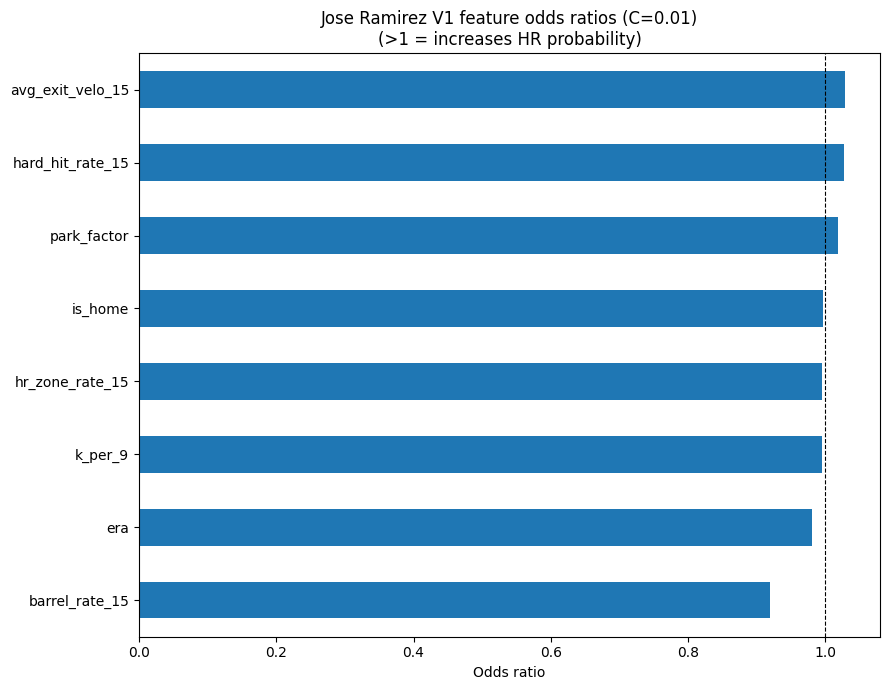


Odds ratios:
barrel_rate_15      0.920
era                 0.981
k_per_9             0.995
hr_zone_rate_15     0.996
is_home             0.996
park_factor         1.019
hard_hit_rate_15    1.028
avg_exit_velo_15    1.029
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era         > 1 — higher ERA = worse pitcher = more HRs
#   k_per_9     < 1 — strikeout pitchers limit balls in play
#   park_factor > 1 — road games in hitter parks are the opportunity
#   is_home     < 1 — Progressive Field park_factor_hr = 63, strongly suppressive
#                     home games should clearly reduce HR probability
#   pitcher_r   DROPPED — switch hitter, handedness neutralized
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Jose Ramirez V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())


Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
604 2025-09-08  0.169067           491  ❌ No HR
605 2025-09-09  0.170729           486     ✅ HR
606 2025-09-10  0.165572           504  ❌ No HR
607 2025-09-11  0.160812           522  ❌ No HR
608 2025-09-12  0.161724           518  ❌ No HR
609 2025-09-13  0.166292           501  ❌ No HR
610 2025-09-14  0.164365           508  ❌ No HR
611 2025-09-16  0.174965           472  ❌ No HR
612 2025-09-17  0.173481           476  ❌ No HR
613 2025-09-18  0.176256           467     ✅ HR
614 2025-09-19  0.173331           477  ❌ No HR
615 2025-09-20  0.173721           476     ✅ HR
616 2025-09-20  0.171958           482  ❌ No HR
617 2025-09-21  0.177284           464  ❌ No HR
618 2025-09-23  0.179399           457  ❌ No HR
619 2025-09-24  0.175698           469  ❌ No HR
620 2025-09-25  0.178987           459  ❌ No HR
621 2025-09-26  0.180160           455  ❌ No HR
622 2025-09-27  0.180730           4

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/ramirez_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/ramirez_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/ramirez_hr_logistic_v1_model.pkl")
print("  models/ramirez_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/ramirez_hr_logistic_v1_model.pkl
  models/ramirez_hr_logistic_v1_scaler.pkl

Best C: 0.01
Features (8): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'era', 'k_per_9', 'park_factor']
